<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [ ]:
import pandas as pd
import numpy as np
from typing import Tuple, List, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from google.colab import drive


In [ ]:
drive.mount('/content/drive')
bank_df = pd.read_csv("drive/MyDrive/DATA LOVE/train.csv")
test_bank_df = pd.read_csv('drive/MyDrive/DATA LOVE/test.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%writefile process_bank_churn.py
import pandas as pd
import numpy as np
from typing import Tuple, List, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

"""
process_bank_churn.py

Модуль для попередньої обробки даних банківського відтоку клієнтів.
"""

def get_feature_columns(
    df: pd.DataFrame
) -> Tuple[List[str], List[str]]:
    """
    Визначає числові та категоріальні колонки у датафреймі.

    Parameters
    ----------
    df : pd.DataFrame
        Вхідний датафрейм з ознаками (без цільової колонки).

    Returns
    -------
    Tuple[List[str], List[str]]
        Кортеж (numeric_cols, categorical_cols).
    """
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    return numeric_cols, categorical_cols


def scale_numeric(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    numeric_cols: List[str]
) -> Tuple[pd.DataFrame, pd.DataFrame, MinMaxScaler]:
    """
    Масштабує числові ознаки за допомогою MinMaxScaler.
    Навчає scaler на тренувальних даних і застосовує до обох наборів.

    Parameters
    ----------
    train_df : pd.DataFrame
        Тренувальний датафрейм.
    val_df : pd.DataFrame
        Валідаційний датафрейм.
    numeric_cols : List[str]
        Список числових колонок для масштабування.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, MinMaxScaler]
        Масштабовані train, val датафрейми та навчений scaler.
    """
    scaler = MinMaxScaler()
    train_df = train_df.copy()
    val_df = val_df.copy()
    train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
    val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
    return train_df, val_df, scaler


def encode_categorical(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    categorical_cols: List[str]
) -> Tuple[pd.DataFrame, pd.DataFrame, OneHotEncoder, List[str]]:
    """
    Кодує категоріальні ознаки за допомогою OneHotEncoder.
    Навчає encoder на тренувальних даних і застосовує до обох наборів.

    Parameters
    ----------
    train_df : pd.DataFrame
        Тренувальний датафрейм.
    val_df : pd.DataFrame
        Валідаційний датафрейм.
    categorical_cols : List[str]
        Список категоріальних колонок для кодування.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, OneHotEncoder, List[str]]
        Закодовані train, val датафрейми, навчений encoder та список нових колонок.
    """
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    train_df = train_df.copy()
    val_df = val_df.copy()
    encoder.fit(train_df[categorical_cols])
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    train_df[encoded_cols] = encoder.transform(train_df[categorical_cols])
    val_df[encoded_cols] = encoder.transform(val_df[categorical_cols])
    return train_df, val_df, encoder, encoded_cols


def preprocess_data(
    bank_df: pd.DataFrame,
    target_col: str = 'Exited',
    test_size: float = 0.2,
    random_state: int = 42,
    scale_numeric_features: bool = True
) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series,
           List[str], Optional[MinMaxScaler], OneHotEncoder]:
    """
    Виконує повну попередню обробку банківських даних.

    Кроки:
    1. Визначення вхідних колонок (без id, CustomerId, Surname, Exited).
    2. Розбиття на train/val зі стратифікацією.
    3. Масштабування числових ознак (опціонально).
    4. One-Hot кодування категоріальних ознак.

    Parameters
    ----------
    bank_df : pd.DataFrame
        Вхідний датафрейм з сирими даними.
    target_col : str
        Назва цільової колонки. За замовчуванням 'Exited'.
    test_size : float
        Частка валідаційного набору. За замовчуванням 0.2.
    random_state : int
        Seed для відтворюваності. За замовчуванням 42.
    scale_numeric_features : bool
        Якщо True — масштабує числові ознаки MinMaxScaler.
        Для дерев рішень можна передати False.

    Returns
    -------
    Tuple:
        X_train : pd.DataFrame
        train_targets : pd.Series
        X_val : pd.DataFrame
        val_targets : pd.Series
        input_cols : List[str]
        scaler : MinMaxScaler або None
        encoder : OneHotEncoder
    """
    # 1. Явно задаємо input_cols як у оригінальному коді
    input_cols = [
        'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
        'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
        'EstimatedSalary'
    ]

    # 2. Розбиття на train/val зі стратифікацією
    train_df, val_df = train_test_split(
        bank_df,
        test_size=test_size,
        random_state=random_state,
        stratify=bank_df[target_col]
    )

    train_inputs = train_df[input_cols].copy()
    train_targets = train_df[target_col]
    val_inputs = val_df[input_cols].copy()
    val_targets = val_df[target_col]

    # 3. Визначаємо типи колонок
    numeric_cols, categorical_cols = get_feature_columns(train_inputs)

    # 4. Масштабування числових (опціонально)
    scaler = None
    if scale_numeric_features and numeric_cols:
        train_inputs, val_inputs, scaler = scale_numeric(
            train_inputs, val_inputs, numeric_cols
        )

    # 5. Кодування категоріальних
    train_inputs, val_inputs, encoder, encoded_cols = encode_categorical(
        train_inputs, val_inputs, categorical_cols
    )

    # 6. Фінальні X з числовими + закодованими колонками
    final_cols = numeric_cols + encoded_cols
    X_train = train_inputs[final_cols]
    X_val = val_inputs[final_cols]

    return X_train, train_targets, X_val, val_targets, final_cols, scaler, encoder


def preprocess_new_data(
    new_df: pd.DataFrame,
    input_cols: List[str],
    encoder: OneHotEncoder,
    scaler: Optional[MinMaxScaler] = None
) -> pd.DataFrame:
    """
    Обробляє нові дані (test.csv) з використанням
    вже навченого scaler та encoder.

    Parameters
    ----------
    new_df : pd.DataFrame
        Новий датафрейм для обробки (наприклад test.csv).
    input_cols : List[str]
        Перелік колонок що використовувались при навчанні.
    encoder : OneHotEncoder
        Навчений encoder.
    scaler : Optional[MinMaxScaler]
        Навчений scaler. Якщо None — масштабування не виконується.

    Returns
    -------
    pd.DataFrame
        Оброблений датафрейм готовий для передбачення моделлю.
    """
    # Ті самі вхідні колонки що при навчанні
    raw_input_cols = [
        'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
        'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
        'EstimatedSalary'
    ]

    df = new_df[raw_input_cols].copy()

    numeric_cols, categorical_cols = get_feature_columns(df)

    # Масштабування числових
    if scaler is not None and numeric_cols:
        df[numeric_cols] = scaler.transform(df[numeric_cols])

    # Кодування категоріальних
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    df[encoded_cols] = encoder.transform(df[categorical_cols])

    # Повертаємо лише потрібні колонки
    final_cols = [col for col in input_cols if col in df.columns]
    return df[final_cols]


Overwriting process_bank_churn.py


https://github.com/OlenaBogoliubova/DATA-LOVE-ACADEMY.git

In [ ]:
from process_bank_churn import preprocess_data, preprocess_new_data

# Для дерев рішень
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = \
    preprocess_data(bank_df, scale_numeric_features=False)

# Для тестових даних
X_test = preprocess_new_data(test_bank_df, input_cols, encoder, scaler)

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

AUROC Train: 1.0000
AUROC Val:   0.7700

Deep of tree: 26


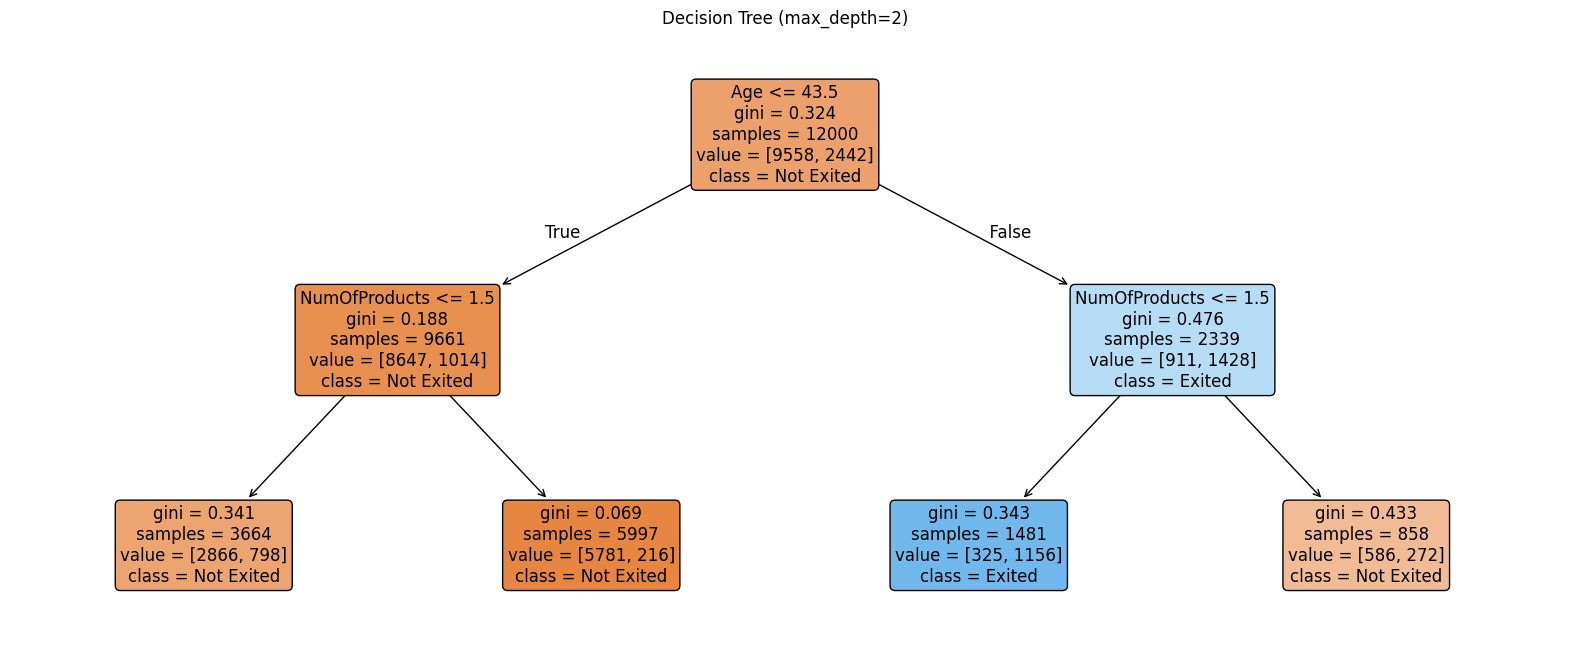


Top 10 Feature Importance:
             feature  importance
0                Age    0.356789
1      NumOfProducts    0.168379
2    EstimatedSalary    0.123635
3        CreditScore    0.123283
4            Balance    0.079192
5             Tenure    0.052899
6     IsActiveMember    0.032688
7      Gender_Female    0.014908
8  Geography_Germany    0.014725
9          HasCrCard    0.012957


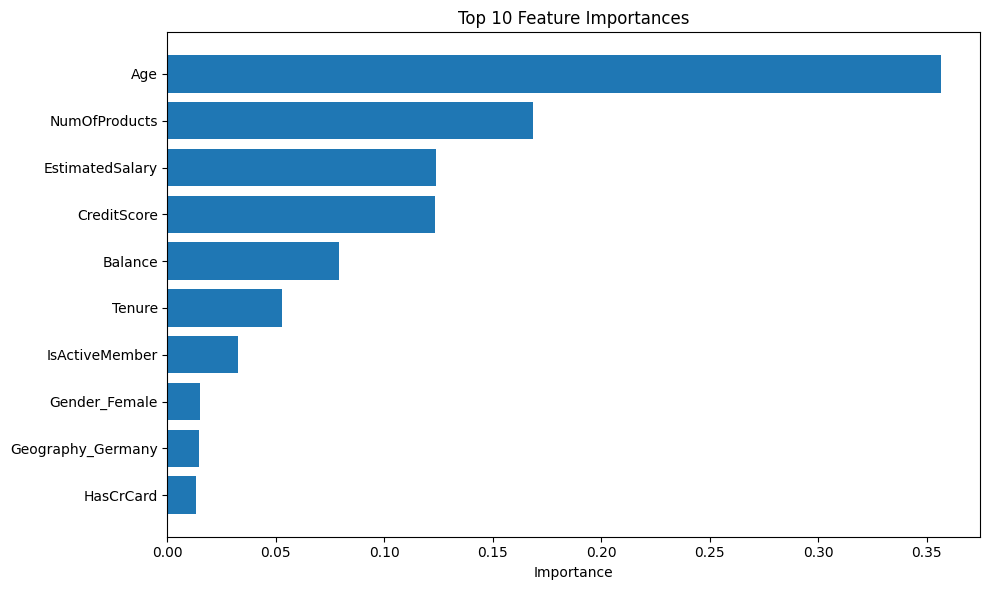

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# 1. Training decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, train_targets)

# 2. AUROC на train and val
train_proba = dt_model.predict_proba(X_train)[:, 1]
val_proba   = dt_model.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(train_targets, train_proba)
val_auc   = roc_auc_score(val_targets,   val_proba)

print(f"AUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")

# 3. Deep of tree
print(f"\nDeep of tree: {dt_model.get_depth()}")

# 4. Deep to 2
dt_model_depth2 = DecisionTreeClassifier(random_state=42, max_depth=2)
dt_model_depth2.fit(X_train, train_targets)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model_depth2,
    feature_names=X_train.columns.tolist(),
    class_names=['Not Exited', 'Exited'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Decision Tree (max_depth=2)')
plt.show()

# 5. Feature Importances
importance_df = pd.DataFrame({
    'feature':    X_train.columns.tolist(),
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 10 Feature Importance:")
print(importance_df.head(10))

# Barplot
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.head(10)['feature'][::-1],
    importance_df.head(10)['importance'][::-1]
)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

Ми бачимо сильне перенавчання — дерево без обмежень глибини вивчило тренувальні дані ідеально (до 100%), але на валідації значно гірше.

Дерево використало лише 2 ознаки:
Age (корінь) — найважливіша ознака. Поріг 43.5 роки ділить клієнтів на дві групи: молодші залишаються, старші частіше йдуть.
NumOfProducts — друга за важливістю. Клієнти з 1 продуктом (≤1.5) і віком >43.5 найчастіше йдуть (синій вузол, 1156 з 1481).

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [ ]:
# Експерименти з параметрами
experiments = [
    {'max_depth': 3},
    {'max_depth': 4},
    {'max_depth': 5},
    {'max_depth': 6},
    {'max_depth': 7},
    {'max_depth': 10},
    {'max_depth': 4, 'max_leaf_nodes': 10},
    {'max_depth': 4, 'max_leaf_nodes': 20},
    {'max_depth': 5, 'max_leaf_nodes': 20},
    {'max_depth': 5, 'max_leaf_nodes': 30},
    {'max_depth': 6, 'max_leaf_nodes': 30},
    {'max_depth': 6, 'max_leaf_nodes': 50},
    {'max_depth': 7, 'max_leaf_nodes': 50},
]

results = []

for params in experiments:
    model = DecisionTreeClassifier(random_state=42, **params)
    model.fit(X_train, train_targets)

    train_auc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auc   = roc_auc_score(val_targets,   model.predict_proba(X_val)[:, 1])

    results.append({
        'max_depth':      params.get('max_depth', '-'),
        'max_leaf_nodes': params.get('max_leaf_nodes', '-'),
        'AUROC Train':    round(train_auc, 4),
        'AUROC Val':      round(val_auc, 4),
        'Gap':            round(train_auc - val_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values('AUROC Val', ascending=False)
print(results_df.to_string(index=False))

 max_depth max_leaf_nodes  AUROC Train  AUROC Val    Gap
         7             50       0.9311     0.9234 0.0077
         6             30       0.9264     0.9227 0.0037
         6             50       0.9326     0.9220 0.0105
         5             30       0.9257     0.9219 0.0038
         5              -       0.9257     0.9219 0.0038
         6              -       0.9338     0.9211 0.0127
         5             20       0.9163     0.9160 0.0003
         7              -       0.9415     0.9144 0.0271
         4              -       0.9113     0.9113 0.0000
         4             20       0.9113     0.9113 0.0000
         4             10       0.9014     0.9000 0.0014
         3              -       0.8972     0.8911 0.0060
        10              -       0.9698     0.8484 0.1213


Найкращий результат при max_depth=7, max_leaf_nodes=50 — найвищий AUROC Val (0.9234) при прийнятному gap (0.0077).
Але якщо в пріоритеті стабільність і відсутність перенавчання, то max_depth=6, max_leaf_nodes=30 дає майже такий самий Val (0.9227) але вдвічі менший gap (0.0037).

In [ ]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_error = 1 - model.score(X_train, train_targets)
    val_error = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [ ]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])
errors_df.style.background_gradient(subset='Validation Error', cmap='Blues_r')

,Max Depth,Training Error,Validation Error
0,1,0.160417,0.177333
1,2,0.134250,0.139000
2,3,0.118500,0.125333
3,4,0.112750,0.118000
4,5,0.104750,0.112667
5,6,0.095917,0.109000
6,7,0.092250,0.110333
7,8,0.081833,0.109667
8,9,0.073667,0.114667
9,10,0.064167,0.117333


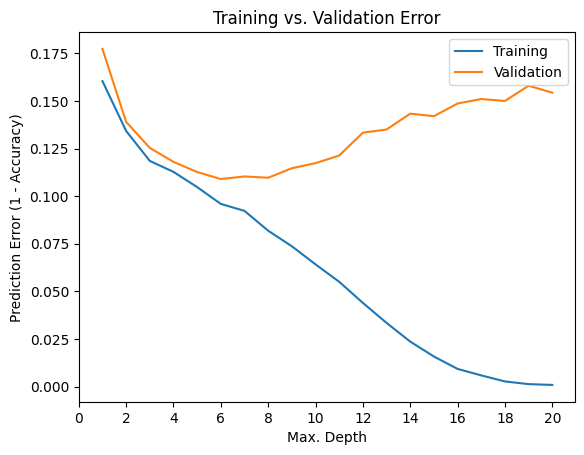

In [ ]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation']);

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

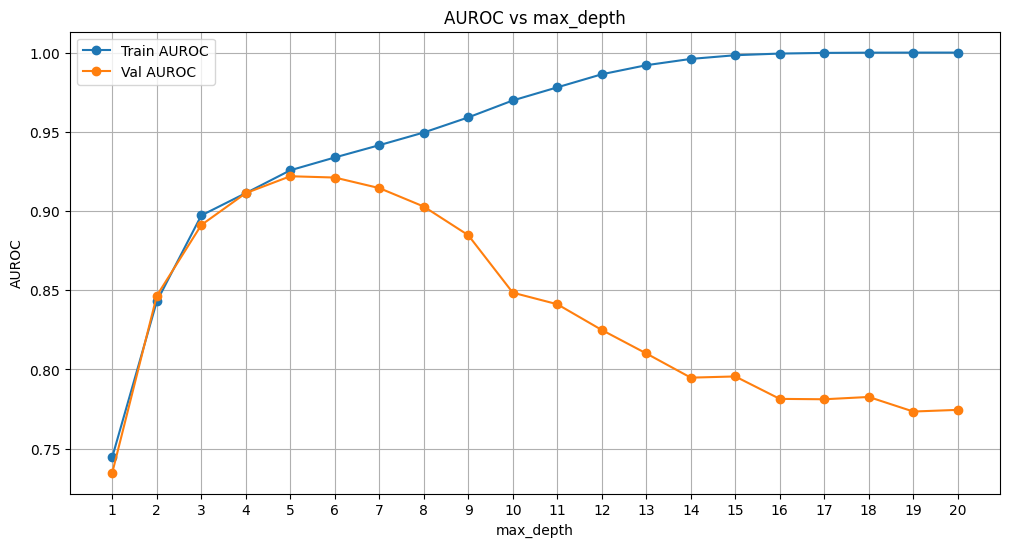

Best max_depth: 5
AUROC Train: 0.9257
AUROC Val:   0.9219


In [ ]:
train_aucs = []
val_aucs   = []
depths     = list(range(1, 21))

for depth in depths:
    model = DecisionTreeClassifier(random_state=42, max_depth=depth)
    model.fit(X_train, train_targets)

    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets,     model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(12, 6))
plt.plot(depths, train_aucs, label='Train AUROC', marker='o')
plt.plot(depths, val_aucs,   label='Val AUROC',   marker='o')
plt.xlabel('max_depth')
plt.ylabel('AUROC')
plt.title('AUROC vs max_depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

best_depth = depths[val_aucs.index(max(val_aucs))]
print(f"Best max_depth: {best_depth}")
print(f"AUROC Train: {train_aucs[best_depth-1]:.4f}")
print(f"AUROC Val:   {max(val_aucs):.4f}")

Оптимальна глибина на max_depth=5 або max_depth=6. Там Val AUROC досягає максимуму (~0.921-0.922) і починає падати.

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [ ]:
# 1. Final model with best max_depth
best_model = DecisionTreeClassifier(random_state=42, max_depth=5)

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([train_targets, val_targets])
best_model.fit(X_full, y_full)

print(f"AUROC Train: {roc_auc_score(train_targets, best_model.predict_proba(X_train)[:, 1]):.4f}")
print(f"AUROC Val:   {roc_auc_score(val_targets,   best_model.predict_proba(X_val)[:, 1]):.4f}")

AUROC Train: 0.9254
AUROC Val:   0.9260


In [ ]:
X_test = preprocess_new_data(
    new_df=test_bank_df,
    input_cols=input_cols,
    encoder=encoder,
    scaler=scaler
)

probs = best_model.predict_proba(X_test)[:, 1]

sample_submission = pd.read_csv('drive/MyDrive/DATA LOVE/sample_submission.csv')
print("Sample submission:")
print(sample_submission.head())

preds_df = pd.DataFrame({
    'id':     test_bank_df['id'],
    'Exited': probs
})

sample_submission = sample_submission.drop(columns=['Exited']).merge(preds_df, on='id', how='left')

print(sample_submission.head())

sample_submission.to_csv('submission_decision_tree.csv', index=False)
print("\nSaved: submission_decision_tree.csv")

import shutil
shutil.copy('submission_decision_tree.csv', '/content/drive/MyDrive/DATA LOVE/submission_decision_tree.csv')
print("Saved on Google Drive!")

Sample submission:
      id  Exited
0  15000     0.5
1  15001     0.5
2  15002     0.5
3  15003     0.5
4  15004     0.5
      id    Exited
0  15000  0.186842
1  15001  0.013561
2  15002  0.013561
3  15003  0.538462
4  15004  0.013561

Saved: submission_decision_tree.csv
Saved on Google Drive!


Нажаль, поки результат вийшов гірший, ніж на поліноміальних ознаках.

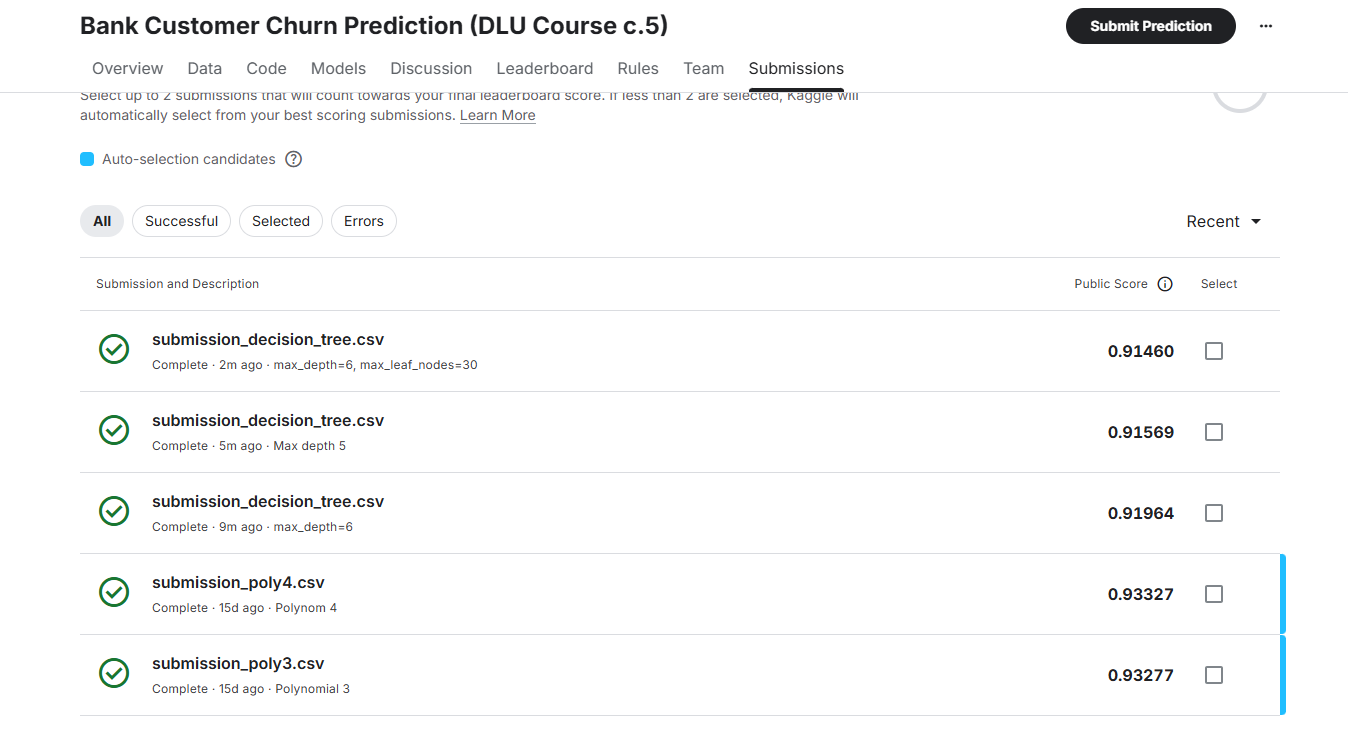